In [ ]:
!pip install -q transformers torchvision albumentations

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!git clone https://github.com/tangsanli5201/DeepPCB.git

Cloning into 'DeepPCB'...
remote: Enumerating objects: 4753, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4753 (delta 13), reused 12 (delta 12), pack-reused 4739 (from 1)
Receiving objects: 100% (4753/4753), 85.81 MiB | 19.41 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Updating files: 100% (4548/4548), done.


In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset


class DeepPCBDataset(Dataset):
    def __init__(self, root_dir, split_file):
        self.root_dir = root_dir

        with open(split_file, "r") as f:
            self.samples = [line.strip().split() for line in f.readlines()]

        # 6 clases
        self.classes = ["open", "short", "mousebite", "spur", "copper", "pin-hole"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_rel_path, ann_rel_path = self.samples[idx]

        img_path = os.path.join(
            self.root_dir,
            img_rel_path.replace(".jpg", "_test.jpg")
        )
        ann_path = os.path.join(self.root_dir, ann_rel_path)

        image = Image.open(img_path).convert("RGB")

        annotations = []

        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    xmin, ymin, xmax, ymax, class_id = parts

                    xmin, ymin, xmax, ymax = map(float, [xmin, ymin, xmax, ymax])
                    class_id = int(class_id)

                    width = xmax - xmin
                    height = ymax - ymin

                    # evitar cajas inválidas
                    if width < 1 or height < 1:
                        continue

                    annotations.append({
                        "bbox": [xmin, ymin, width, height],
                        "category_id": class_id,
                        "area": width * height,
                        "iscrowd": 0
                    })

        target = {
            "image_id": idx,
            "annotations": annotations
        }

        return image, target

In [ ]:
ROOT_DIR = "/content/DeepPCB/PCBData"
SPLIT_FILE = "/content/DeepPCB/PCBData/trainval.txt"

dataset = DeepPCBDataset(ROOT_DIR, SPLIT_FILE)

print("Samples:", len(dataset))
print("Clases:", dataset.classes)

Samples: 1000
Clases: ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']


In [ ]:
img, target = dataset[0]

print(img.size)
print(target)

(640, 640)
{'image_id': 0, 'annotations': [{'bbox': [409.0, 394.0, 26.0, 28.0], 'category_id': 3, 'area': 728.0, 'iscrowd': 0}, {'bbox': [275.0, 383.0, 44.0, 34.0], 'category_id': 3, 'area': 1496.0, 'iscrowd': 0}, {'bbox': [8.0, 163.0, 28.0, 28.0], 'category_id': 4, 'area': 784.0, 'iscrowd': 0}, {'bbox': [244.0, 151.0, 26.0, 31.0], 'category_id': 5, 'area': 806.0, 'iscrowd': 0}, {'bbox': [338.0, 519.0, 26.0, 24.0], 'category_id': 6, 'area': 624.0, 'iscrowd': 0}, {'bbox': [476.0, 460.0, 26.0, 21.0], 'category_id': 4, 'area': 546.0, 'iscrowd': 0}]}


In [ ]:
import torch
from torch.utils.data import random_split

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 800
Test size: 200


In [ ]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor

# Processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Mapeo de clases (6 defectos)
id2label = {
    0: "open",
    1: "short",
    2: "mousebite",
    3: "spur",
    4: "copper",
    5: "pin-hole",
}

label2id = {v: k for k, v in id2label.items()}

# Modelo con 6 clases
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Modelo listo en:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsam

Modelo listo en: cuda


In [ ]:
from torch.utils.data import DataLoader

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

def collate_fn(batch):
    images = [item[0] for item in batch]
    annotations = [item[1] for item in batch]

    encoding = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt"
    )

    return {
        "pixel_values": encoding["pixel_values"],
        "labels": encoding["labels"]
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("Collate y loaders listos")

Collate y loaders listos


In [ ]:
import torch
import json
import os
from torch.utils.data import DataLoader, random_split
from google.colab import drive

# =========================
# DRIVE
# =========================
drive.mount('/content/drive')

# =========================
# CONFIG
# =========================
lr = 5e-5
batch_size = 4
epochs = 30
patience = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# =========================
# SAVE DIR
# =========================
save_dir = "/content/drive/MyDrive/entrenamiento_detr"
os.makedirs(save_dir, exist_ok=True)

# =========================
# SPLIT DATASET (REPRODUCIBLE)
# =========================
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# =========================
# DATALOADERS (OPTIMIZADOS)
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

# =========================
# HISTORIAL
# =========================
history = {
    "train_loss": [],
    "val_loss": []
}

config = {
    "learning_rate": lr,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "AdamW"
}

# =========================
# BEST MODEL + EARLY STOP
# =========================
best_val_loss = float("inf")
epochs_no_improve = 0

# =========================
# TRAIN LOOP
# =========================
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    total_train_loss = 0.0

    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)

        labels = [
            {k: v.to(device) for k, v in t.items()}
            for t in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()

        # CLIPPING
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / max(len(train_loader), 1)

    # -------- VALIDATION --------
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)

            labels = [
                {k: v.to(device) for k, v in t.items()}
                for t in batch["labels"]
            ]

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / max(len(val_loader), 1)

    # -------- HISTORIAL --------
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    # -------- GUARDAR MEJOR MODELO --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_loss": avg_val_loss
        }, os.path.join(save_dir, "best_model.pth"))

        print("Mejor modelo guardado")

    else:
        epochs_no_improve += 1

    # -------- EARLY STOPPING --------
    if epochs_no_improve >= patience:
        print("Early stopping activado")
        break

    torch.cuda.empty_cache()

# =========================
# GUARDADO FINAL
# =========================
torch.save(model.state_dict(), os.path.join(save_dir, "model_final.pth"))

with open(os.path.join(save_dir, "history.json"), "w") as f:
    json.dump(history, f)

with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config, f)

print("Todo guardado en Drive")

Mounted at /content/drive
Train batches: 200
Val batches: 50
Epoch 1/30 | Train: 2.2443 | Val: 1.7950
Mejor modelo guardado
Epoch 2/30 | Train: 1.7175 | Val: 1.6768
Mejor modelo guardado
Epoch 3/30 | Train: 1.5855 | Val: 1.5107
Mejor modelo guardado
Epoch 4/30 | Train: 1.5530 | Val: 1.5323
Epoch 5/30 | Train: 1.4570 | Val: 1.4514
Mejor modelo guardado
Epoch 6/30 | Train: 1.3760 | Val: 1.3720
Mejor modelo guardado
Epoch 7/30 | Train: 1.2430 | Val: 1.1971
Mejor modelo guardado
Epoch 8/30 | Train: 1.2187 | Val: 1.1152
Mejor modelo guardado
Epoch 9/30 | Train: 1.1562 | Val: 1.0709
Mejor modelo guardado
Epoch 10/30 | Train: 1.0374 | Val: 0.9296
Mejor modelo guardado
Epoch 11/30 | Train: 0.9436 | Val: 0.9076
Mejor modelo guardado
Epoch 12/30 | Train: 0.8423 | Val: 0.7771
Mejor modelo guardado
Epoch 13/30 | Train: 0.8144 | Val: 0.6997
Mejor modelo guardado
Epoch 14/30 | Train: 0.7458 | Val: 0.7146
Epoch 15/30 | Train: 0.7675 | Val: 0.6864
Mejor modelo guardado
Epoch 16/30 | Train: 0.6719 | Va

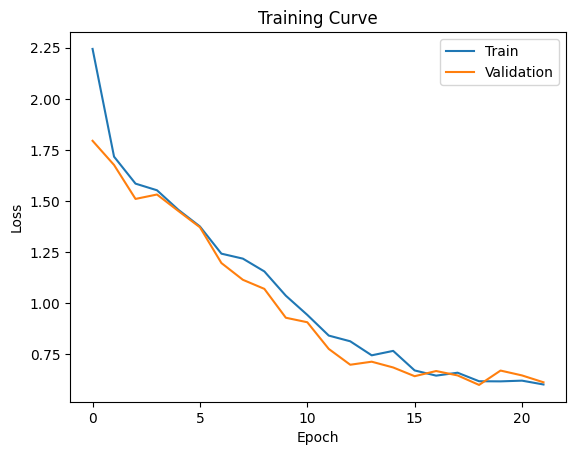

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.show()

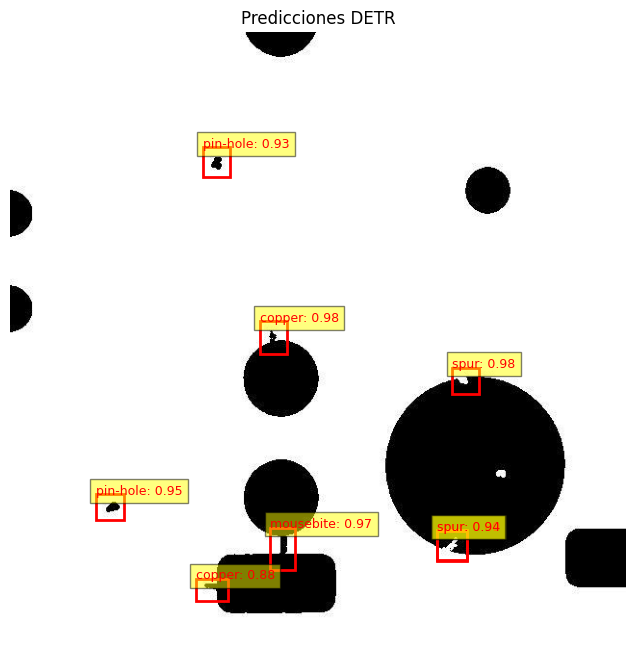

In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()

# Tomar una muestra
image, target = dataset[10]

# DETR espera lista de imágenes
inputs = processor(images=[image], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-processing
results = processor.post_process_object_detection(
    outputs,
    target_sizes=[(image.size[1], image.size[0])],  # (h, w)
    threshold=0.5
)[0]

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(image)

# Si no hay detecciones, evitar crash
if len(results["boxes"]) == 0:
    print("No se detectaron objetos")

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):
    xmin, ymin, xmax, ymax = box.cpu().numpy()

    # Dibujar bounding box
    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )

    # Mostrar label + score
    class_name = model.config.id2label[label.item()]
    score_value = score.item()

    plt.text(
        xmin,
        ymin,
        f"{class_name}: {score_value:.2f}",
        color="red",
        fontsize=9,
        bbox=dict(facecolor="yellow", alpha=0.5)
    )

plt.axis("off")
plt.title("Predicciones DETR")
plt.show()